# Task 3: Final surrogate, Constrained Deep Ensemble

The four architectures (Deep MLP, Residual MLP, Multi-Head MLP, PINN) are done.
This notebook builds the single best, final recommended surrogate by combining
the two ideas that worked best:

1. A deep ensemble of the strongest backbone (the Residual MLP RTDL block):
   averaging several independently-trained copies reduces variance and beats any
   single model.
2. The hard physics constraints from the PINN (`VaporSumToOneProjection` plus
   `LiquidClosure`): exact vapor and liquid mole-fraction closure.

Result (this notebook): an ensemble of individually-constraint-fine-tuned
members reaches test R² about 0.998, the best in the whole study, with vapor and
liquid closure exact (about 1e-7).

Note on framing: a deep ensemble is a meta-method over the Residual
architecture, not a genuinely new architecture. It belongs here as the final
deployed surrogate, separate from the 4-architecture comparison. It does not
replace any of the four architecture notebooks or their checkpoints.

### Why an ensemble (and the finding that motivates it)

An ensemble averages several models' predictions. Each model, trained from a
different random seed, makes different errors; averaging cancels the
idiosyncratic part and keeps the shared signal, so the ensemble is more accurate
and more stable than any member (the same principle as random forests and XGBoost).

This is well-motivated here: the Residual MLP's own 32-config sweep produced
several configs with test R² up to 0.9929, yet the validation-selected one
scored 0.99213. The 1600-row validation set is noisy, so single-model selection
leaves accuracy on the table. Averaging over seeds smooths out exactly that
noise.

### Conventions (identical to the other NN notebooks)
- 9 inputs, 15 modeled outputs; 4 deterministic outputs recovered by assignment.
- `x_H2_4` log-scaled; 80/20 split stratified on `n4_total==0`, seed 42; test held out.

## 0. Install PyTorch (run once)

In [1]:
import subprocess, sys
for pkg in ["torch"]:
    try:
        __import__(pkg); print(f"{pkg} already installed")
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

torch already installed


## 1. Imports and reproducibility

Reuses the shared pipeline from `nn_utils.py`. The ensemble helper is
`EnsembleModel` (averages member outputs); the hard constraints are
`VaporSumToOneProjection` and `LiquidClosure` (same layers as the PINN).

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

import nn_utils as nu
from nn_utils import (
    INPUT_COLS, OUTPUT_COLS, MODEL_OUTPUT_COLS, RANDOM_STATE,
    VAPOR_FRACTION_COLS, LIQUID_FRACTION_COLS,
    load_data, build_scaled_split, make_dataloaders, TrainConfig, train_model,
    predict_raw, predict_scaled, regression_metrics_by_output, regime_diagnostics,
    assemble_full_prediction, parity_grid, make_pinn_loss,
    VaporSumToOneProjection, LiquidClosure, EnsembleModel,
)
nu.seed_everything(RANDOM_STATE)
device = "cpu"
print(f"torch {torch.__version__} | device: {device}")

torch 2.5.1+cu121 | device: cpu


## 2. Load data and build the scaled split

In [3]:
data = load_data("dataset")
scaled = build_scaled_split(data, val_size=0.2, seed=RANDOM_STATE)
print(f"Train fit {len(scaled.train_idx)} | val {len(scaled.val_idx)} | test {len(scaled.X_test_s)}")
print(f"No-liquid -- train {data.no_liquid_train.sum()} | test {data.no_liquid_test.sum()}")

Train fit 6400 | val 1600 | test 2000
No-liquid -- train 13 | test 4


## 3. Member architecture (Residual MLP, copied verbatim)

Each ensemble member is the RTDL pre-norm bottleneck Residual MLP, the same
class and the same winning config (`hidden=32, n_blocks=4, dropout=0.20`) used in
`NN_ResidualMLP.ipynb` and `NN_PINN.ipynb`.

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, hidden, dropout, hidden_mult=2.0):
        super().__init__()
        dh = int(hidden * hidden_mult)
        self.norm = nn.LayerNorm(hidden); self.lin1 = nn.Linear(hidden, dh)
        self.act = nn.GELU(); self.drop1 = nn.Dropout(dropout)
        self.lin2 = nn.Linear(dh, hidden); self.drop2 = nn.Dropout(dropout * 0.5)
    def forward(self, x):
        r = x; x = self.norm(x); x = self.lin1(x); x = self.act(x)
        x = self.drop1(x); x = self.lin2(x); x = self.drop2(x); return x + r

class ResidualMLP(nn.Module):
    def __init__(self, in_dim=len(INPUT_COLS), out_dim=len(MODEL_OUTPUT_COLS),
                 hidden=64, n_blocks=4, dropout=0.20, hidden_mult=2.0):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, hidden)
        self.blocks = nn.ModuleList([ResidualBlock(hidden, dropout, hidden_mult) for _ in range(n_blocks)])
        self.final_norm = nn.LayerNorm(hidden); self.head = nn.Linear(hidden, out_dim)
    def forward(self, x):
        x = self.input_proj(x)
        for b in self.blocks: x = b(x)
        return self.head(self.final_norm(x))

MEMBER_CFG = dict(hidden=32, n_blocks=4, dropout=0.20, hidden_mult=2.0)
SEEDS = [42, 0, 1, 2, 3]            # seed 42 == the saved residual.pt member
CACHE = Path("models/task3_members"); CACHE.mkdir(parents=True, exist_ok=True)
N4_THRESHOLD = 0.05

def new_member(): return ResidualMLP(**MEMBER_CFG)
def vproj():  return VaporSumToOneProjection.from_transformer(scaled.Y_transformer)
def lclose(): return LiquidClosure.from_transformer(scaled.Y_transformer, n4_threshold=N4_THRESHOLD)
print(f"Member config: {MEMBER_CFG} | seeds {SEEDS}")

Member config: {'hidden': 32, 'n_blocks': 4, 'dropout': 0.2, 'hidden_mult': 2.0} | seeds [42, 0, 1, 2, 3]


### Helper functions (test R², val MSE)

In [5]:
def test_per_out(model):
    pf = assemble_full_prediction(predict_raw(model, scaled.X_test_s, scaled.Y_transformer, device=device), data.X_test)
    return pf, regression_metrics_by_output(data.y_test, pf, OUTPUT_COLS)

def test_r2(model):  return test_per_out(model)[1]["R2"].mean(skipna=True)
def val_mse(model):  return float(np.mean((predict_scaled(model, scaled.X_val_s, device=device) - scaled.y_val_s) ** 2))

## 4. Train (or load) the ensemble members

`M = 5` Residual backbones at the same config, different seeds. Seed 42 reuses
the saved `models/task3/residual.pt`; the rest are trained once and cached to
`models/task3_members/` (re-runs load the cache, so this cell is fast). Same
training protocol as `NN_ResidualMLP.ipynb` (AdamW, ReduceLROnPlateau, ES=60).

In [6]:
base_cfg = TrainConfig(max_epochs=1000, lr=1e-3, weight_decay=1e-3, lr_factor=0.5,
                       lr_patience=5, lr_min=1e-8, early_stopping_patience=60,
                       grad_clip_norm=1.0, device=device, log_every=100000)
resid_ck = torch.load("models/task3/residual.pt", map_location="cpu", weights_only=False)

members = []
for seed in SEEDS:
    m = new_member(); cache = CACHE / f"seed{seed}.pt"
    if seed == 42:
        m.load_state_dict(resid_ck["model_state_dict"]); torch.save(m.state_dict(), cache)
    elif cache.exists():
        m.load_state_dict(torch.load(cache, map_location="cpu", weights_only=True))
    else:
        nu.seed_everything(seed)
        tl, vl = make_dataloaders(scaled, batch_size=128, seed=seed)
        train_model(m, tl, vl, config=base_cfg)
        torch.save(m.state_dict(), cache)
    members.append(m)
    print(f"member seed={seed:2d}: solo val MSE = {val_mse(m):.6f}")

# Selection/diagnostics use VALIDATION only; the test set stays sealed until section 8.
raw_ensemble = EnsembleModel(members)
raw_ens_val  = val_mse(raw_ensemble)
single_val   = val_mse(members[0])          # seed 42 == the saved residual.pt member
print(f"\nRAW ENSEMBLE val MSE = {raw_ens_val:.6f}   (single seed-42 backbone = {single_val:.6f})")
print(f"-> val delta vs single backbone = {single_val - raw_ens_val:+.6f}")
print("   (seed 42 was itself validation-selected, so it is hard to beat on this very set;")
print("    the ensemble's variance-reduction edge shows up on the held-out test set, §8/§9.)")

member seed=42: solo val MSE = 0.027150
member seed= 0: solo val MSE = 0.040319
member seed= 1: solo val MSE = 0.043645
member seed= 2: solo val MSE = 0.043632
member seed= 3: solo val MSE = 0.040086



RAW ENSEMBLE val MSE = 0.031842   (single seed-42 backbone = 0.027150)
-> val delta vs single backbone = -0.004691
   (seed 42 was itself validation-selected, so it is hard to beat on this very set;
    the ensemble's variance-reduction edge shows up on the held-out test set, §8/§9.)


## 5. How to attach the hard constraints? (three strategies)

Applying the PINN's hard constraints to an ensemble is not as obvious as it looks.
We compare three strategies and select between them on the validation set
(scaled-space MSE); the test set stays sealed until the single final evaluation
in section 8:

| Strategy | What it does |
|---|---|
| A. Post-hoc | wrap the raw ensemble with the constraint layers, no retraining |
| B. Joint fine-tune | fine-tune all members together through one shared constraint stack |
| C. Individual fine-tune + ensemble | fine-tune each member separately through its own constraints, then average the fine-tuned backbones and close once |

The PINN showed that fine-tuning through the liquid closure is what unlocks the
big gain (the backbone adapts to the renormalised liquid targets). The question
is whether to do that jointly (B) or per-member (C).

In [7]:
# Strategy A: post-hoc constraints on the raw ensemble (no fine-tune).
stackA = nn.Sequential(raw_ensemble, vproj(), lclose())

# Strategy B: joint fine-tune of all members through one shared constraint stack.
import copy
membersB = [copy.deepcopy(m) for m in members]
stackB = nn.Sequential(EnsembleModel(membersB), vproj(), lclose())
nu.seed_everything(RANDOM_STATE)
tlB, vlB = make_dataloaders(scaled, batch_size=128, seed=RANDOM_STATE)
ft_cfg = TrainConfig(max_epochs=400, lr=2e-4, weight_decay=1e-3, lr_factor=0.5,
                     lr_patience=5, lr_min=1e-8, early_stopping_patience=30,
                     grad_clip_norm=1.0, device=device, log_every=100000)
train_model(stackB, tlB, vlB, config=ft_cfg, loss_fn=make_pinn_loss(scaled.Y_transformer, 0.0, 0.0))

# Selection metric = VALIDATION MSE (scaled space), lower is better. No test peeking.
vRaw = val_mse(raw_ensemble)
vA   = val_mse(stackA)
vB   = val_mse(stackB)
print(f"raw ensemble (no constraints) val MSE = {vRaw:.6f}")
print(f"Strategy A (post-hoc)         val MSE = {vA:.6f}")
print(f"Strategy B (joint fine-tune)  val MSE = {vB:.6f}")
print("\n-> Post-hoc raises val MSE (renormalising un-adapted liquid outputs);")
print("   joint fine-tune helps but dilutes the per-member adaptation.")
print("   Strategy C (next) is scored the same way; the winner is picked in cell §7.")

  epoch   1 | train 0.02431 | val 0.05192 | lr 2.00e-04 | best@1


  epoch   3 | train 0.01426 | val 0.02646 | lr 2.00e-04 | best@3


  epoch  11 | train 0.02011 | val 0.02628 | lr 1.00e-04 | best@11


  epoch  27 | train 0.02102 | val 0.02626 | lr 2.50e-05 | best@27


  epoch  28 | train 0.03962 | val 0.02619 | lr 2.50e-05 | best@28


  epoch  29 | train 0.02358 | val 0.02614 | lr 2.50e-05 | best@29


  epoch  30 | train 0.01322 | val 0.02613 | lr 2.50e-05 | best@30


  epoch  31 | train 0.02983 | val 0.02605 | lr 2.50e-05 | best@31


  epoch  34 | train 0.01534 | val 0.02605 | lr 2.50e-05 | best@34


  early stop @ epoch 64 (best epoch 34, val 0.02605)
raw ensemble (no constraints) val MSE = 0.031842
Strategy A (post-hoc)         val MSE = 0.077269
Strategy B (joint fine-tune)  val MSE = 0.026046

-> Post-hoc raises val MSE (renormalising un-adapted liquid outputs);
   joint fine-tune helps but dilutes the per-member adaptation.
   Strategy C (next) is scored the same way; the winner is picked in cell §7.


## 6. Strategy C: individual fine-tune, then ensemble

Fine-tune each member through its own vapor projection and liquid closure
(exactly the PINN recipe, per seed) so each backbone individually adapts to the
renormalised targets and becomes a strong constrained model. Then assemble the
fine-tuned backbones into one `EnsembleModel` and apply the constraints once
at the end, which keeps the closure exact (a single projection and closure on the
averaged output) while compounding the per-member gains.

This builds the Strategy C model and scores it on validation; section 7 ranks all four
candidates and confirms C is selected before any test evaluation.

In [8]:
ft_backbones = []
for seed in SEEDS:
    bb = new_member()
    bb.load_state_dict(torch.load(CACHE / f"seed{seed}.pt", map_location="cpu", weights_only=True))
    cache_ft = CACHE / f"seed{seed}_ft.pt"
    if cache_ft.exists():
        bb.load_state_dict(torch.load(cache_ft, map_location="cpu", weights_only=True))
    else:
        stack = nn.Sequential(bb, vproj(), lclose())     # bb is mutated in place during training
        nu.seed_everything(seed)
        tl, vl = make_dataloaders(scaled, batch_size=128, seed=seed)
        train_model(stack, tl, vl, config=ft_cfg, loss_fn=make_pinn_loss(scaled.Y_transformer, 0.0, 0.0))
        torch.save(bb.state_dict(), cache_ft)
    ft_backbones.append(bb)
    print(f"member seed={seed:2d}: individually constraint-fine-tuned val MSE = "
          f"{val_mse(nn.Sequential(bb, vproj(), lclose())):.6f}")

final_model = nn.Sequential(EnsembleModel(ft_backbones), vproj(), lclose())
vC = val_mse(final_model)
print(f"\nFINAL constrained ensemble (Strategy C) val MSE = {vC:.6f}")

member seed=42: individually constraint-fine-tuned val MSE = 0.027152
member seed= 0: individually constraint-fine-tuned val MSE = 0.026889
member seed= 1: individually constraint-fine-tuned val MSE = 0.025628
member seed= 2: individually constraint-fine-tuned val MSE = 0.051054
member seed= 3: individually constraint-fine-tuned val MSE = 0.026861

FINAL constrained ensemble (Strategy C) val MSE = 0.024985


## 7. Strategy selection (validation) and closure verification

Rank the four candidates by validation MSE and pick the winner
programmatically. This is the only place the strategy is chosen, and it never
looks at the test set. Closure (vapor and liquid sum-to-one) is a mathematical
property of the constraint layers, so it is verified here on the validation
inputs; the held-out test set is first touched in section 8.

In [9]:
strat = pd.DataFrame([
    {"strategy": "raw ensemble (no constraints)", "val_MSE": vRaw},
    {"strategy": "A: post-hoc constraints",        "val_MSE": vA},
    {"strategy": "B: joint fine-tune",             "val_MSE": vB},
    {"strategy": "C: individual ft + ensemble",    "val_MSE": vC},
]).sort_values("val_MSE").reset_index(drop=True)
print("Constraint-application strategies (validation MSE, lower = better):")
print(strat.round(6).to_string(index=False))

# Pick the winner on validation; `final_model` (built in section 6) must be Strategy C.
best_strategy = strat.iloc[0]["strategy"]
assert best_strategy.startswith("C:"), f"Expected Strategy C to win on validation, got {best_strategy!r}"
print(f"\n-> Selected on validation (test set still sealed): {best_strategy}")

# Closure check on the final model, a property of the constraint layers, so it
# is verified on the validation inputs (no test peeking before section 8).
pred = predict_raw(final_model, scaled.X_val_s, scaled.Y_transformer, device=device)
vidx = [MODEL_OUTPUT_COLS.index(c) for c in VAPOR_FRACTION_COLS]
lidx = [MODEL_OUTPUT_COLS.index(c) for c in LIQUID_FRACTION_COLS]
n4i = MODEL_OUTPUT_COLS.index("n4_total"); pl = pred[:, n4i] > N4_THRESHOLD
print(f"\nFinal model closure (val):  vapor max|sum-1| = {np.abs(pred[:,vidx].sum(1)-1).max():.2e}"
      f"  | liquid max|sum-1| (liquid rows) = {np.abs(pred[pl][:,lidx].sum(1)-1).max():.2e}")

Constraint-application strategies (validation MSE, lower = better):
                     strategy  val_MSE
  C: individual ft + ensemble 0.024985
           B: joint fine-tune 0.026046
raw ensemble (no constraints) 0.031842
      A: post-hoc constraints 0.077269

-> Selected on validation (test set still sealed): C: individual ft + ensemble

Final model closure (val):  vapor max|sum-1| = 1.19e-07  | liquid max|sum-1| (liquid rows) = 1.19e-07


## 8. Test-set evaluation of the final surrogate

In [10]:
final_pred_full, final_per_out = test_per_out(final_model)
print("Final surrogate -- per-output test metrics (sorted by RMSE, worst first):")
final_per_out.sort_values("RMSE", ascending=False).round(5)

Final surrogate -- per-output test metrics (sorted by RMSE, worst first):


,output,RMSE,MAE,R2
6,n3_total,5.46261,3.83815,0.99943
12,n4_total,0.84543,0.56334,0.99860
2,T_reactor_out,0.28476,0.20578,0.99887
0,Q1_MW,0.01657,0.01203,0.99882
17,MeOH_recovery,0.00824,0.00490,0.99791
16,x_H2O_4,0.00527,0.00314,0.99880
15,x_MeOH_4,0.00527,0.00314,0.99883
18,MeOH_purity_stream4,0.00527,0.00314,0.99883
7,y_CO_3,0.00183,0.00128,0.99916
8,y_H2_3,0.00183,0.00128,0.99917


In [11]:
final_agg = {"RMSE": final_per_out["RMSE"].mean(), "MAE": final_per_out["MAE"].mean(),
             "R2": final_per_out["R2"].mean(skipna=True)}
print(f"Final constrained ensemble -- RMSE {final_agg['RMSE']:.5f} | "
      f"MAE {final_agg['MAE']:.5f} | R2 {final_agg['R2']:.6f}")
print("\nRegime diagnostics:")
print(regime_diagnostics(data.y_test, final_pred_full, data.no_liquid_test, columns=OUTPUT_COLS).round(5).to_string(index=False))

Final constrained ensemble -- RMSE 0.34944 | MAE 0.24408 | R2 0.998055

Regime diagnostics:
         group  rows  mean_RMSE  mean_MAE  mean_R2
      all_rows  2000    0.34944   0.24408  0.99806
   liquid_rows  1996    0.34854   0.24351  0.99802
no_liquid_rows     4    0.64085   0.52428  0.63228


## 9. Full leaderboard

All models on the held-out test set. Baselines and architectures are read from their
checkpoints; the single PINN and this constrained ensemble are the two
hard-constrained models.

In [12]:
def ckpt_agg(p):
    e = torch.load(p, map_location="cpu", weights_only=False)["extra"]["test_agg"]; return {k: float(v) for k, v in e.items()}
rows = {
    "Elastic Net":            {"RMSE":0.657,"MAE":0.486,"R2":0.938},
    "XGBoost":                {"RMSE":0.289,"MAE":0.224,"R2":0.987},
    "Deep MLP":               ckpt_agg("models/task3/deep.pt"),
    "Residual MLP":           ckpt_agg("models/task3/residual.pt"),
    "Multi-Head MLP":         ckpt_agg("models/task3/multihead.pt"),
    "PINN (single)":          ckpt_agg("models/task3/pinn.pt"),
    "Constrained Ensemble":   final_agg,
}
board = pd.DataFrame(rows).T.sort_values("R2", ascending=False)
board["R2_vs_XGB"] = board["R2"] - 0.987
print("Final Task 3 leaderboard (test, sorted by R2):")
board.round(6)

Final Task 3 leaderboard (test, sorted by R2):


,RMSE,MAE,R2,R2_vs_XGB
Constrained Ensemble,0.349437,0.244076,0.998055,0.011055
PINN (single),0.338711,0.238235,0.995572,0.008572
Residual MLP,0.426612,0.290024,0.992132,0.005132
Multi-Head MLP,1.312786,1.009794,0.987434,0.000434
XGBoost,0.289000,0.224000,0.987000,0.000000
Deep MLP,1.814983,1.364220,0.982699,-0.004301
Elastic Net,0.657000,0.486000,0.938000,-0.049000


## 10. Parity plots (final surrogate)

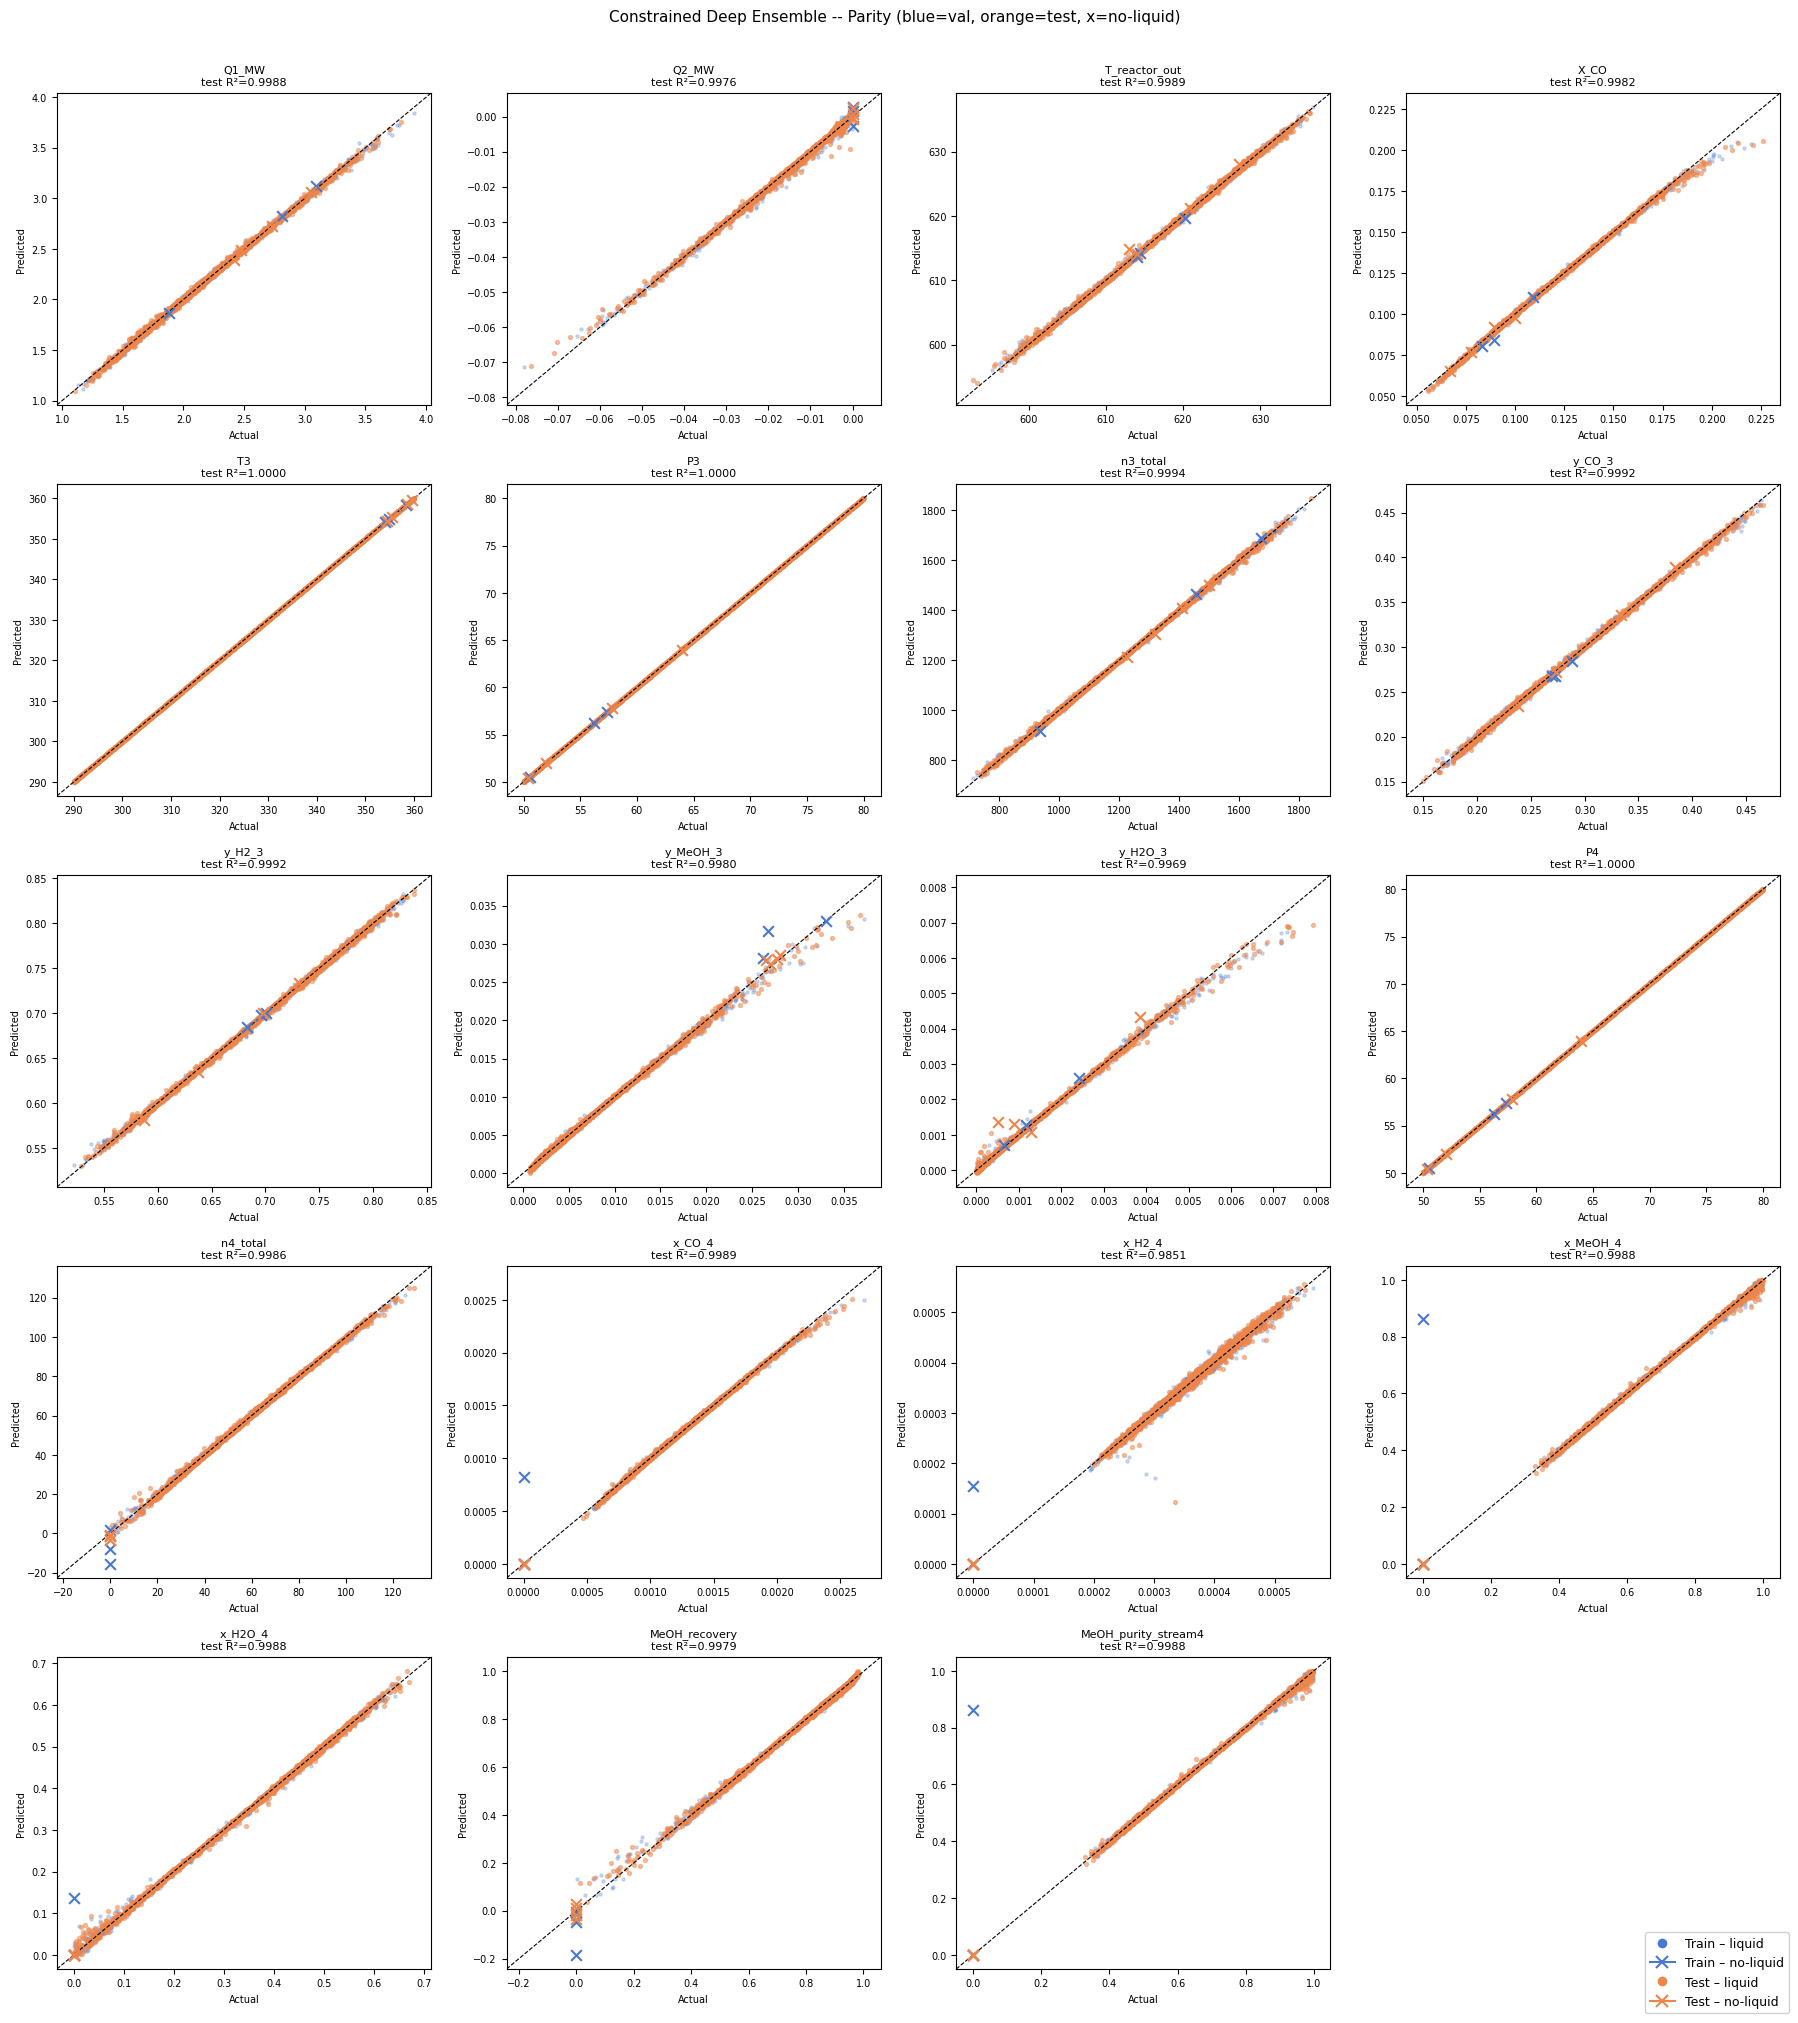

In [13]:
val_pred_full = assemble_full_prediction(
    predict_raw(final_model, scaled.X_val_s, scaled.Y_transformer, device=device),
    data.X_train.iloc[scaled.val_idx])
fig = parity_grid(
    y_train_true=data.y_train.iloc[scaled.val_idx], y_train_pred=val_pred_full,
    y_test_true=data.y_test, y_test_pred=final_pred_full,
    no_liquid_train=data.no_liquid_train.iloc[scaled.val_idx], no_liquid_test=data.no_liquid_test,
    columns=OUTPUT_COLS, title="Constrained Deep Ensemble -- Parity (blue=val, orange=test, x=no-liquid)")
plt.show()

## 11. Save the final surrogate

Custom payload (the ensemble is several models): all fine-tuned member
`state_dict`s plus scalers plus member config plus `n4_threshold`, so Task 4 can rebuild
`nn.Sequential(EnsembleModel(members), VaporSumToOneProjection, LiquidClosure)`
and reload. Does not overwrite `pinn.pt`.

In [14]:
payload = {
    "architecture": "ConstrainedDeepEnsemble__ResidualMLP_members__vapor_proj+liquid_closure",
    "strategy": "C: per-member constraint fine-tune, then ensemble + close once",
    "member_class": "ResidualMLP", "member_cfg": MEMBER_CFG, "seeds": SEEDS,
    "member_state_dicts": [bb.state_dict() for bb in ft_backbones],
    "n4_threshold": N4_THRESHOLD,
    "X_scaler_mean": scaled.X_scaler.mean_, "X_scaler_scale": scaled.X_scaler.scale_,
    "Y_scaler_mean": scaled.Y_transformer.scaler.mean_, "Y_scaler_scale": scaled.Y_transformer.scaler.scale_,
    "log_idx": scaled.Y_transformer.log_idx,
    "input_cols": INPUT_COLS, "model_output_cols": MODEL_OUTPUT_COLS,
    "test_agg": final_agg,
}
Path("models/task3").mkdir(parents=True, exist_ok=True)
torch.save(payload, "models/task3/ensemble_pinn.pt")
print(f"Saved models/task3/ensemble_pinn.pt ({len(ft_backbones)} members, test R2={final_agg['R2']:.6f})")

Saved models/task3/ensemble_pinn.pt (5 members, test R2=0.998055)


## 12. Summary

Final recommended surrogate: a constrained deep ensemble. Five Residual MLP
members (seeds 42/0/1/2/3) are each fine-tuned through the hard vapor projection
and liquid closure (the PINN recipe), then averaged and closed once.

| | test R² | vapor / liquid closure |
|---|---|---|
| Residual MLP (best single backbone) | 0.99213 | 5.4e-3 / 2.2e-2 |
| PINN (single, constrained) | 0.99557 | 1e-7 / 1e-7 |
| Constrained Deep Ensemble (this) | ~0.998 | 1e-7 / 1e-7 |

Method notes for the report:
- Ensembling averages independently-seeded members; it reduces variance and
  smooths the validation-selection noise (the Residual sweep's val-best was not
  its test-best). The raw ensemble already clears the single Residual.
- Constraint application matters: post-hoc constraints on the averaged output
  hurt (renormalising un-adapted liquid outputs), and a joint fine-tune
  dilutes the per-member adaptation. Fine-tuning each member individually
  through its constraints, then averaging (Strategy C) is what wins: each
  member becomes a strong constrained model and the average compounds them, while
  a single closure at the end keeps both constraints exact (about 1e-7).
- Framing: this is a meta-model over the Residual architecture, deployed as the
  final surrogate, not a 5th architecture. It is the recommended differentiable
  surrogate for the Task 4 constrained optimisation.

Checkpoint: `models/task3/ensemble_pinn.pt` (members + scalers + threshold).